# Modeling Notebook 

## Importing the necessary libraries

In [1]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
import xgboost as xgb
import cv2
import torch
import timm
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

import torch.nn.functional as F

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

# Tabular only pipeline

In [2]:
DATA_PATH = "/kaggle/input/cdc-house/train_processed.csv"
IMAGE_DIR = "/kaggle/input/train-sat-img/train_sat"

df = pd.read_csv(DATA_PATH)
df['image_path'] = '/kaggle/input/train-sat-img/train_sat/house_' + df['id'].astype(str) + '.png'

df.drop(columns=['log_price','id'],axis=1,inplace=True)
TARGET = "price"

In [3]:
X_tab = df.drop(columns=[TARGET, "image_path"])
y = df[TARGET]

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X_tab, y, test_size=0.2, random_state=42
)

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


In [6]:
xgb_model = xgb.XGBRegressor(
    n_estimators=2000,
    max_depth=6,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42
)

xgb_model.fit(
    X_train_scaled,
    y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.02, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=None, num_parallel_tree=None, ...)

In [7]:
val_preds = xgb_model.predict(X_val_scaled)

rmse = mean_squared_error(y_val, val_preds)**0.5
r2 = r2_score(y_val, val_preds)

print(f"[XGBoost Baseline] RMSE: {rmse:.4f}")
print(f"[XGBoost Baseline] R2_score : {r2:.4f}")

[XGBoost Baseline] RMSE: 109629.8984
[XGBoost Baseline] R2_score : 0.8929


## Tabular + Image Feature Extraction Model

In [8]:
%pip install -q timm xgboost opencv-python

Note: you may need to restart the kernel to use updated packages.


In [9]:
CSV_PATH = "/kaggle/input/cdc-house/train_processed.csv"
IMG_DIR  = "/kaggle/input/train-sat-img/train_sat"

df = pd.read_csv(CSV_PATH)
df['image_path'] = 'house_'+df['id'].astype(str)+'.png'

In [10]:
# df = df[(df['price'] >= df['price'].quantile(0.01)) & (df['price'] <= df['price'].quantile(0.99))]

In [11]:
df

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,long,sqft_living15,sqft_lot15,year,month,log_price,house_age,lat_long_interaction,is_renovated,image_path
0,9117000170,268643,4,2.25,1810,9240,2.0,0,0,3,...,-122.187,1660,9240,1,5,12.501139,54,-5796.086969,0,house_9117000170.png
1,6700390210,245000,3,2.50,1600,2788,2.0,0,0,4,...,-122.187,1720,3605,0,7,12.409013,23,-5792.079236,0,house_6700390210.png
2,7212660540,200000,4,2.50,1720,8638,2.0,0,0,3,...,-122.313,1870,7455,1,1,12.206073,21,-5781.784435,0,house_7212660540.png
3,8562780200,352499,2,2.25,1240,705,2.0,0,0,3,...,-122.073,1240,750,1,4,12.772803,6,-5802.386043,0,house_8562780200.png
4,7760400350,232000,3,2.00,1280,13356,1.0,0,0,3,...,-122.074,1590,8071,0,12,12.354493,21,-5782.828491,0,house_7760400350.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16203,5272200045,378000,3,1.50,1000,6914,1.0,0,0,3,...,-122.319,1000,6947,0,11,12.842649,68,-5836.377694,0,house_5272200045.png
16204,9578500790,399950,3,2.50,3087,5002,2.0,0,0,3,...,-122.349,2927,5183,0,11,12.899095,1,-5786.789593,0,house_9578500790.png
16205,7202350480,575000,3,2.50,2120,4780,2.0,0,0,3,...,-122.032,1690,2650,0,9,13.262125,11,-5818.607792,0,house_7202350480.png
16206,1723049033,245000,1,0.75,380,15000,1.0,0,0,3,...,-122.323,1170,15000,0,6,12.409013,52,-5808.018363,0,house_1723049033.png


In [12]:
df.drop(columns=['price'],axis=1,inplace=True)

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
from torchvision import models, transforms
import torch

cnn = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

cnn = cnn.to(device)
# cnn.eval()

In [15]:
img_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [16]:
def grad_cam(row):
    img_path = f"{IMG_DIR}/{row['image_path']}"
    img_pil = Image.open(img_path).convert("RGB")
    x = img_tf(img_pil).unsqueeze(0).to(device)

    out = cnn(x)
    cls = out.argmax()
    cnn.zero_grad()
    out[0, cls].backward()

    weights = gradients.mean(dim=(2,3), keepdim=True)
    cam = (weights * activations).sum(dim=1)
    cam = F.relu(cam).squeeze().detach().cpu().numpy()

    cam = cv2.resize(cam, img_pil.size)
    cam = (cam - cam.min()) / (cam.max() + 1e-8)

    img = np.array(img_pil)/255.0
    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)/255.0
    overlay = 0.5*img + 0.5*heatmap

    plt.imshow(overlay)
    plt.title(f"Price: {int(np.expm1(row['log_price']))}")
    plt.axis("off")
    plt.show()

In [17]:
activations = None
gradients = None

def forward_hook(_, __, output):
    global activations
    activations = output

def backward_hook(_, grad_in, grad_out):
    global gradients
    gradients = grad_out[0]

cnn.layer4[-1].register_forward_hook(forward_hook)
cnn.layer4[-1].register_backward_hook(backward_hook)

## Grad-cam Visualization 

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


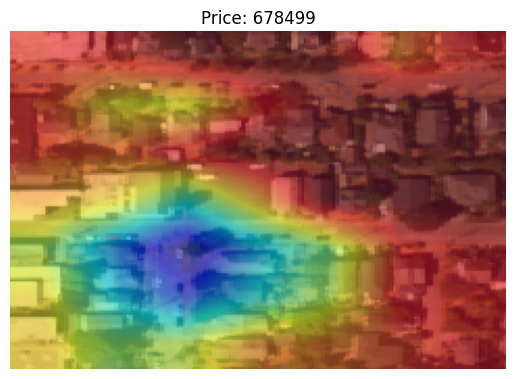

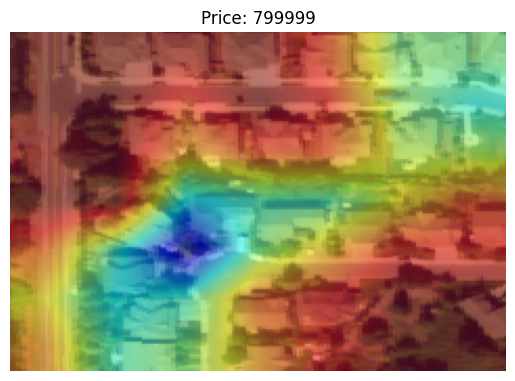

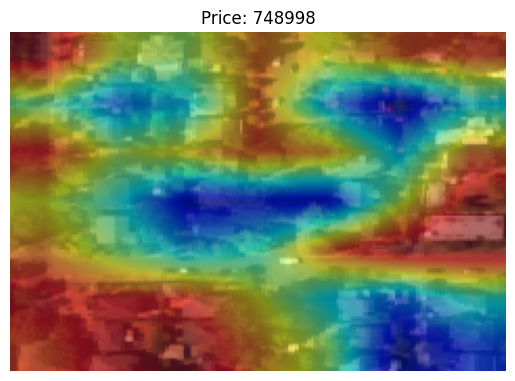

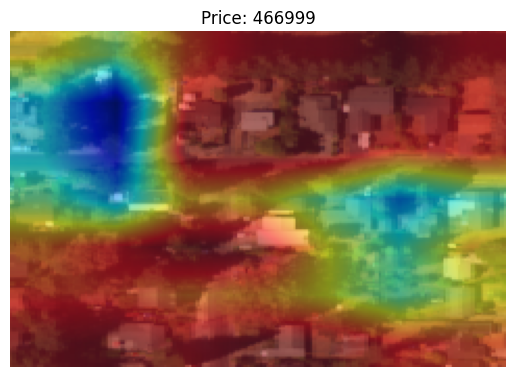

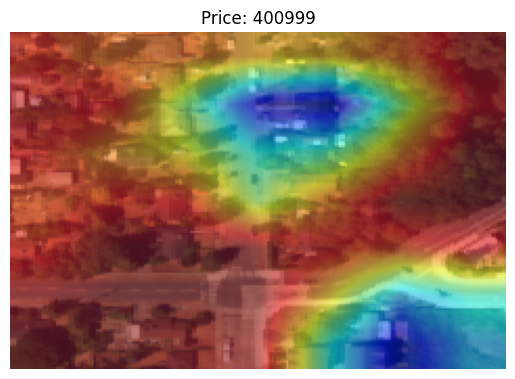

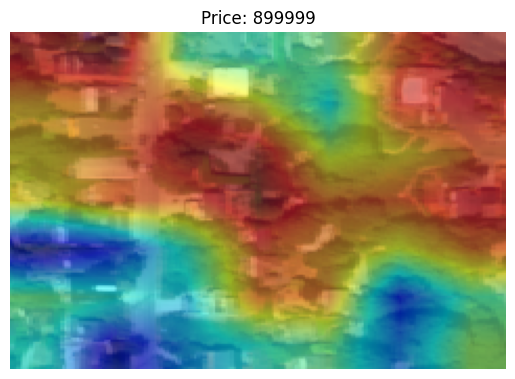

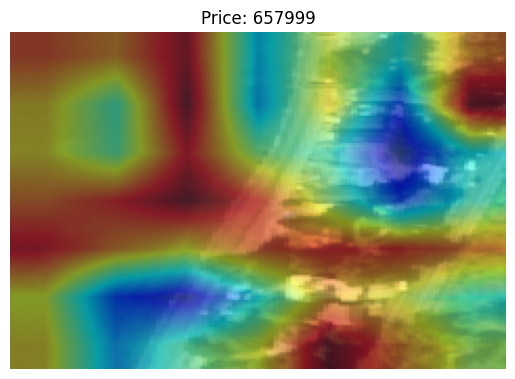

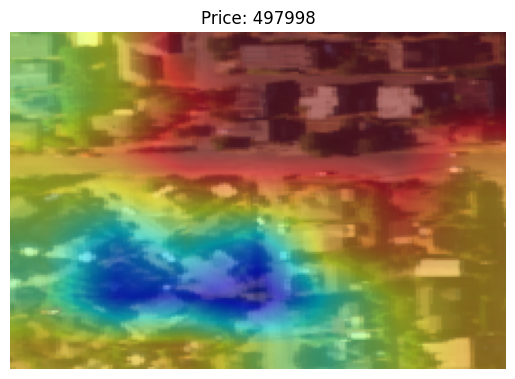

In [18]:
for _, row in df.sample(n=8).iterrows():
    grad_cam(row)

The gradcam analysis signifies that the areas which are crowded and some vegetation is supposed to have more prices. Also structured houses have higher prices.

In [19]:
def extract_image_features(img_path):
    feats = {
        # basic
        "green_ratio": 0.0,
        "water_ratio": 0.0,
        "edge_density": 0.0,
        "brightness_mean": 0.0,

        # texture
        "texture_lap_var": 0.0,
        "glcm_contrast": 0.0,
        "glcm_homogeneity": 0.0,
        "glcm_energy": 0.0,

        # structure
        "edge_orient_entropy": 0.0,
        "road_proxy": 0.0,

        # spatial
        "green_spread": 0.0,
        "shadow_ratio": 0.0,

        # color
        "color_entropy": 0.0,
    }

    if not os.path.exists(img_path):
        return feats

    img = cv2.imread(img_path)
    if img is None:
        return feats

    img = cv2.resize(img, (224,224))
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ---------------- GREEN & WATER ----------------
    green = (
        (hsv[:,:,0] > 35) & (hsv[:,:,0] < 85) &
        (hsv[:,:,1] > 40) & (hsv[:,:,2] > 40)
    )

    water = (
        (hsv[:,:,0] > 90) & (hsv[:,:,0] < 130) &
        (hsv[:,:,1] > 50)
    )

    feats["green_ratio"] = green.mean()
    feats["water_ratio"] = water.mean()

    # ---------------- EDGES ----------------
    edges = cv2.Canny(gray, 100, 200)
    feats["edge_density"] = (edges > 0).mean()

    kernel = np.ones((3,3), np.uint8)
    edges_dilated = cv2.dilate(edges, kernel)
    feats["road_proxy"] = (edges_dilated > 0).mean()

    # ---------------- TEXTURE ----------------
    lap = cv2.Laplacian(gray, cv2.CV_64F)
    feats["texture_lap_var"] = np.log1p(lap.var())

    # GLCM
    gray_q = (gray / 8).astype(np.uint8)  # quantize
    glcm = graycomatrix(gray_q, distances=[1], angles=[0],
                        levels=32, symmetric=True, normed=True)

    feats["glcm_contrast"] = graycoprops(glcm, 'contrast')[0,0]
    feats["glcm_homogeneity"] = graycoprops(glcm, 'homogeneity')[0,0]
    feats["glcm_energy"] = graycoprops(glcm, 'energy')[0,0]

    # ---------------- EDGE ORIENTATION ----------------
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    angle = np.arctan2(gy, gx)
    hist, _ = np.histogram(angle, bins=16, range=(-np.pi, np.pi), density=True)
    feats["edge_orient_entropy"] = entropy(hist + 1e-6)

    # ---------------- GREEN SPREAD ----------------
    green_uint8 = green.astype(np.uint8)
    num_labels, labels = cv2.connectedComponents(green_uint8)
    feats["green_spread"] = num_labels / (224*224)

    # ---------------- SHADOW RATIO ----------------
    shadow = (hsv[:,:,2] < 50) & (hsv[:,:,1] < 80)
    feats["shadow_ratio"] = shadow.mean()

    # ---------------- COLOR ENTROPY ----------------
    hist_rgb = np.histogram(img.reshape(-1,3), bins=32, density=True)[0]
    feats["color_entropy"] = entropy(hist_rgb + 1e-6)

    # ---------------- BRIGHTNESS ----------------
    feats["brightness_mean"] = hsv[:,:,2].mean() / 255.0

    return feats


In [20]:
def add_image_features(df, img_dir):
    feats = []
    for pid in tqdm(df['image_path']):
        feats.append(extract_image_features(f"{img_dir}/{pid}"))
    return pd.concat([df.reset_index(drop=True), pd.DataFrame(feats)], axis=1)

In [21]:
train_df = add_image_features(df, IMG_DIR)

100%|██████████| 16208/16208 [04:57<00:00, 54.40it/s]


In [22]:
train_df.columns

Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'year', 'month', 'log_price',
       'house_age', 'lat_long_interaction', 'is_renovated', 'image_path',
       'green_ratio', 'water_ratio', 'edge_density', 'brightness_mean',
       'texture_lap_var', 'glcm_contrast', 'glcm_homogeneity', 'glcm_energy',
       'edge_orient_entropy', 'road_proxy', 'green_spread', 'shadow_ratio',
       'color_entropy'],
      dtype='object')

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
sq = ['sqft_living','sqft_lot','sqft_above','sqft_lot15','sqft_living15','sqft_basement']

train_df[sq] = np.log1p(train_df[sq])
sq = sq+['lat','long','lat_long_interaction']
train_df[sq] = scaler.fit_transform(train_df[sq])

In [24]:
train_df.columns

Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'year', 'month', 'log_price',
       'house_age', 'lat_long_interaction', 'is_renovated', 'image_path',
       'green_ratio', 'water_ratio', 'edge_density', 'brightness_mean',
       'texture_lap_var', 'glcm_contrast', 'glcm_homogeneity', 'glcm_energy',
       'edge_orient_entropy', 'road_proxy', 'green_spread', 'shadow_ratio',
       'color_entropy'],
      dtype='object')

In [25]:
TARGET = "log_price"

X = train_df.drop(columns=[TARGET,'id', "image_path"])
y = train_df[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=56
)


In [26]:
model = XGBRegressor(
    n_jobs=-1,
    n_estimators=2500,
    learning_rate=0.02,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

[0]	validation_0-rmse:0.51210
[100]	validation_0-rmse:0.20394
[200]	validation_0-rmse:0.17153
[300]	validation_0-rmse:0.16473
[400]	validation_0-rmse:0.16148
[500]	validation_0-rmse:0.15953
[600]	validation_0-rmse:0.15901
[700]	validation_0-rmse:0.15883
[800]	validation_0-rmse:0.15860
[900]	validation_0-rmse:0.15851
[1000]	validation_0-rmse:0.15837
[1100]	validation_0-rmse:0.15828
[1200]	validation_0-rmse:0.15824
[1300]	validation_0-rmse:0.15814
[1400]	validation_0-rmse:0.15812
[1500]	validation_0-rmse:0.15811
[1600]	validation_0-rmse:0.15807
[1700]	validation_0-rmse:0.15799
[1800]	validation_0-rmse:0.15796
[1900]	validation_0-rmse:0.15795
[2000]	validation_0-rmse:0.15795
[2100]	validation_0-rmse:0.15793
[2200]	validation_0-rmse:0.15794
[2300]	validation_0-rmse:0.15787
[2400]	validation_0-rmse:0.15784
[2499]	validation_0-rmse:0.15784


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.02, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [27]:
model.get_booster().get_score(importance_type="gain")

{'bedrooms': 0.2550908625125885,
 'bathrooms': 0.9161497354507446,
 'sqft_living': 10.483417510986328,
 'sqft_lot': 0.501446545124054,
 'floors': 0.23527616262435913,
 'waterfront': 1.6243785619735718,
 'view': 1.6530768871307373,
 'condition': 0.6841866374015808,
 'grade': 28.176713943481445,
 'sqft_above': 0.8421189785003662,
 'sqft_basement': 0.2625076174736023,
 'yr_built': 0.728253185749054,
 'yr_renovated': 0.46147799491882324,
 'zipcode': 0.7217714190483093,
 'lat': 7.467218399047852,
 'long': 1.2206370830535889,
 'sqft_living15': 2.066364049911499,
 'sqft_lot15': 0.5152344107627869,
 'year': 0.5772092342376709,
 'month': 0.3321327269077301,
 'house_age': 1.0250730514526367,
 'lat_long_interaction': 2.750148296356201,
 'is_renovated': 0.39274799823760986,
 'green_ratio': 0.25942376255989075,
 'water_ratio': 0.254243940114975,
 'edge_density': 0.2533940374851227,
 'brightness_mean': 0.23448114097118378,
 'texture_lap_var': 0.21743977069854736,
 'glcm_contrast': 0.2304084450006485

In [28]:
preds = model.predict(X_val)
rmse = mean_squared_error(y_val, preds)**0.5
r2 = r2_score(y_val,preds)
print("RMSE:", rmse)
print("R2:", r2)

print("Real RMSE:", mean_squared_error(np.expm1(y_val), np.expm1(preds))**0.5)
print("Real R2 score:", r2_score(np.expm1(y_val), np.expm1(preds)))

RMSE: 0.1578436970966135
R2: 0.9077964642284678
Real RMSE: 104710.39637550407
Real R2 score: 0.9068588449568842


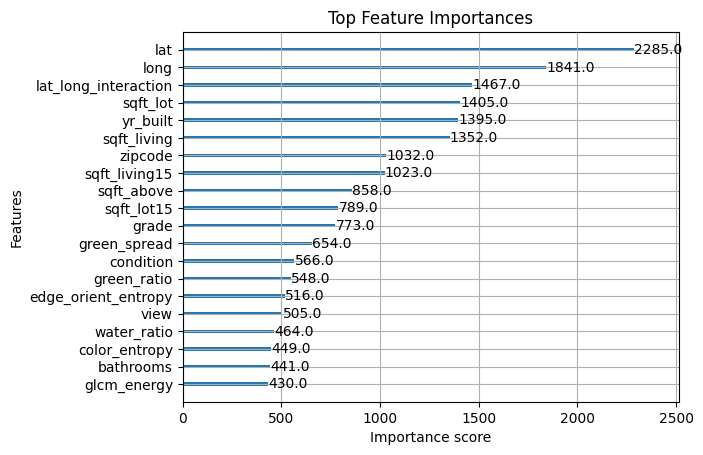

In [ ]:
import xgboost as xgb
xgb.plot_importance(model, max_num_features=20)
plt.title("Top Feature Importances")
plt.show()

## Generating test predictions

In [30]:
test_df = pd.read_csv('/kaggle/input/cdc-house/test.csv')
test_df

,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2591820310,20141006T000000,4,2.25,2070,8893,2.0,0,0,4,8,2070,0,1986,0,98058,47.4388,-122.162,2390,7700
1,7974200820,20140821T000000,5,3.00,2900,6730,1.0,0,0,5,8,1830,1070,1977,0,98115,47.6784,-122.285,2370,6283
2,7701450110,20140815T000000,4,2.50,3770,10893,2.0,0,2,3,11,3770,0,1997,0,98006,47.5646,-122.129,3710,9685
3,9522300010,20150331T000000,3,3.50,4560,14608,2.0,0,2,3,12,4560,0,1990,0,98034,47.6995,-122.228,4050,14226
4,9510861140,20140714T000000,3,2.50,2550,5376,2.0,0,0,3,9,2550,0,2004,0,98052,47.6647,-122.083,2250,4050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5399,7732500270,20140925T000000,4,2.50,2820,15000,2.0,0,0,4,9,2820,0,1985,0,98052,47.7255,-122.101,2440,15000
5400,3856903515,20141222T000000,3,2.00,1460,6250,1.5,0,0,4,7,1460,0,1912,0,98103,47.6693,-122.333,1690,4750
5401,2557000400,20150409T000000,3,2.50,2070,9900,1.0,0,0,3,8,1420,650,1979,0,98023,47.2988,-122.371,2070,8250
5402,4386700135,20141114T000000,4,2.25,4760,8036,2.5,0,0,5,9,3390,1370,1916,0,98112,47.6415,-122.285,2950,9323


In [31]:
test_df['year']=test_df['date'].str[:4].astype(int)
test_df['month'] = test_df['date'].str[4:6].astype(int)
test_df['image_path'] = 'house_' + test_df['id'].astype(str) + '.png'
test_df.drop(columns='date', axis=1, inplace=True)

In [32]:
test_df['zipcode']=test_df['zipcode']-98000
test_df['year'] = test_df['year'] - 2014

test_df['house_age'] = 2015 - test_df['yr_built'] # Since the data is till 2015, we will take that as a reference
test_df['lat_long_interaction']=test_df['lat']*test_df['long']
test_df['is_renovated'] = (test_df['yr_renovated'] > 0).astype(int)

In [33]:
df_test = add_image_features(test_df, '/kaggle/input/test-sat/test_sat')
df_test

100%|██████████| 5404/5404 [01:40<00:00, 53.88it/s]


,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,brightness_mean,texture_lap_var,glcm_contrast,glcm_homogeneity,glcm_energy,edge_orient_entropy,road_proxy,green_spread,shadow_ratio,color_entropy
0,2591820310,4,2.25,2070,8893,2.0,0,0,4,8,...,0.435246,6.240297,3.243854,0.660119,0.131008,2.739371,0.531170,0.006477,0.0,3.032783
1,7974200820,5,3.00,2900,6730,1.0,0,0,5,8,...,0.404092,6.001530,2.799648,0.661877,0.134640,2.746633,0.477978,0.003567,0.0,3.058616
2,7701450110,4,2.50,3770,10893,2.0,0,2,3,11,...,0.435657,5.783547,2.245015,0.674484,0.125308,2.749177,0.469368,0.004464,0.0,3.067135
3,9522300010,3,3.50,4560,14608,2.0,0,2,3,12,...,0.352921,5.819057,2.326153,0.721149,0.301385,2.761324,0.378866,0.003488,0.0,2.882082
4,9510861140,3,2.50,2550,5376,2.0,0,0,3,9,...,0.507109,6.577961,4.515375,0.586026,0.118703,2.753948,0.647421,0.004524,0.0,3.082445
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5399,7732500270,4,2.50,2820,15000,2.0,0,0,4,9,...,0.402169,5.952635,2.819787,0.647574,0.126671,2.754858,0.504564,0.003787,0.0,3.069169
5400,3856903515,3,2.00,1460,6250,1.5,0,0,4,7,...,0.434819,5.764643,2.259249,0.677429,0.128832,2.749126,0.447146,0.004783,0.0,3.132914
5401,2557000400,3,2.50,2070,9900,1.0,0,0,3,8,...,0.389797,6.059669,2.939482,0.656220,0.136193,2.754165,0.491769,0.004325,0.0,3.015469
5402,4386700135,4,2.25,4760,8036,2.5,0,0,5,9,...,0.398402,5.680282,2.161996,0.697062,0.158799,2.763362,0.406310,0.001933,0.0,2.952372


In [34]:
sq = ['sqft_living','sqft_lot','sqft_above','sqft_lot15','sqft_living15','sqft_basement']

df_test[sq] = np.log1p(df_test[sq])
sq = sq+['lat','long','lat_long_interaction']
df_test[sq] = scaler.transform(df_test[sq])
X_test  = df_test.drop(["image_path","id"],axis=1)

In [35]:
X_test

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,brightness_mean,texture_lap_var,glcm_contrast,glcm_homogeneity,glcm_energy,edge_orient_entropy,road_proxy,green_spread,shadow_ratio,color_entropy
0,4,2.25,0.206104,0.121881,2.0,0,0,4,8,0.567265,...,0.435246,6.240297,3.243854,0.660119,0.131008,2.739371,0.531170,0.006477,0.0,3.032783
1,5,3.00,1.002953,-0.186941,1.0,0,0,5,8,0.277815,...,0.404092,6.001530,2.799648,0.661877,0.134640,2.746633,0.477978,0.003567,0.0,3.058616
2,4,2.50,1.623091,0.346677,2.0,0,2,3,11,1.975647,...,0.435657,5.783547,2.245015,0.674484,0.125308,2.749177,0.469368,0.004464,0.0,3.067135
3,3,3.50,2.072798,0.671870,2.0,0,2,3,12,2.422623,...,0.352921,5.819057,2.326153,0.721149,0.301385,2.761324,0.378866,0.003488,0.0,2.882082
4,3,2.50,0.698966,-0.435850,2.0,0,0,3,9,1.057134,...,0.507109,6.577961,4.515375,0.586026,0.118703,2.753948,0.647421,0.004524,0.0,3.082445
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5399,4,2.50,0.936836,0.701216,2.0,0,0,4,9,1.293559,...,0.402169,5.952635,2.819787,0.647574,0.126671,2.754858,0.504564,0.003787,0.0,3.069169
5400,3,2.00,-0.618849,-0.268933,1.5,0,0,4,7,-0.252679,...,0.434819,5.764643,2.259249,0.677429,0.128832,2.749126,0.447146,0.004783,0.0,3.132914
5401,3,2.50,0.206104,0.240753,1.0,0,0,3,8,-0.317916,...,0.389797,6.059669,2.939482,0.656220,0.136193,2.754165,0.491769,0.004325,0.0,3.015469
5402,4,2.25,2.174266,0.009590,2.5,0,0,5,9,1.726040,...,0.398402,5.680282,2.161996,0.697062,0.158799,2.763362,0.406310,0.001933,0.0,2.952372


In [36]:
preds = model.predict(X_test)
test_predictions = pd.DataFrame({
    'id': df_test['id'].values,
    "predicted_price": np.expm1(preds)
})

test_predictions.to_csv('24115013_final.csv',index=False)

## Dumping the trained model and scaling parameters

In [ ]:
import joblib

joblib.dump(scaler, "scaler.joblib")
model.save_model("xgb_model.json")